In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = layers.Input(shape=(784,))
x = layers.Dense(128, activation='relu')(inputs)

z_mean = layers.Dense(2)(x)
z_log_var = layers.Dense(2)(x)

In [ ]:
def sampling(args):
      mean, log_var = args
      epsilon = tf.random.normal(shape=tf.shape(mean))
      return mean + tf.exp(0.5 * log_var) * epsilon

In [ ]:
z = layers.Lambda(sampling)([z_mean, z_log_var])

In [ ]:
decoder_input = layers.Input(shape=(2,))
x = layers.Dense(128, activation='relu')(decoder_input)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder = tf.keras.Model(decoder_input, decoder_output)

In [ ]:
encoded = tf.keras.Model(inputs, z)
vae_output = decoder(z)

vae = tf.keras.Model(inputs, vae_output)

In [16]:
vae.compile(
      optimizer='adam',
          loss='binary_crossentropy'
          )


In [17]:
vae.fit(
      x_train,
          x_train,
              epochs=5,
                  batch_size=128
)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.2588
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2164
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2061
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2016
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1989


In [18]:
random_latent = np.random.normal(
      size=(1,2)
      )

generated = decoder.predict(random_latent)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


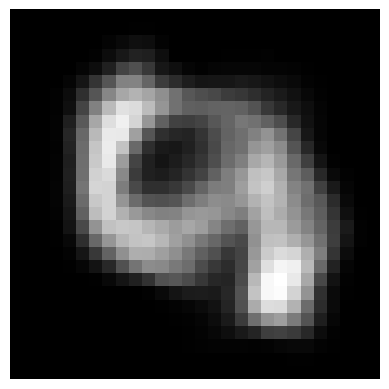

In [19]:
plt.imshow(
      generated[0].reshape(28,28),
          cmap='gray'
          )

plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


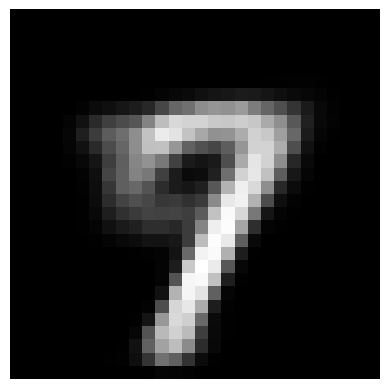

In [20]:
reconstructed = vae.predict(x_test[:1])

plt.imshow(
    reconstructed[0].reshape(28,28),
        cmap='gray'
        )

plt.axis('off')
plt.show()